## PRT564 — Data Analytics & Visualisation
### Data Preprocessing & Exploratory Data Analysis


In [1]:
import os

BASE   = r"C:\Users\ranas\OneDrive\Desktop\Rana_Research_Workspace\Rana_Research_Workspace"
RAW    = os.path.join(BASE, "Raw_Dataset")
CLEAN  = os.path.join(BASE, "Clean_Dataset")
GRAPHS = os.path.join(BASE, "EDA_Graphs")

os.makedirs(CLEAN,  exist_ok=True)
os.makedirs(GRAPHS, exist_ok=True)

for p, name in [(RAW,"Raw_Dataset"), (CLEAN,"Clean_Dataset"), (GRAPHS,"EDA_Graphs")]:
    print(name, "found" if os.path.exists(p) else "NOT FOUND")

Raw_Dataset found
Clean_Dataset found
EDA_Graphs found


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
PALETTE = sns.color_palette('tab10', 8)
print("libraries loaded")

libraries loaded


In [3]:
CITIES       = ['Sydney','Melbourne','Brisbane','Adelaide','Perth','Hobart','Darwin','Canberra']
CITIES_W_AVG = CITIES + ['Weighted_Avg']
STATES       = ['NSW','Vic','Qld','SA','WA','Tas','NT','ACT','Australia']
CITY_TO_STATE = {
    'Sydney':'NSW', 'Melbourne':'Vic', 'Brisbane':'Qld', 'Adelaide':'SA',
    'Perth':'WA',   'Hobart':'Tas',    'Darwin':'NT',    'Canberra':'ACT'
}

In [4]:
def parse_abs(path, sheet='Data1'):
    raw  = pd.read_excel(path, sheet_name=sheet, header=None)
    data = raw.iloc[10:].copy()
    data = data.rename(columns={data.columns[0]: 'quarter'})
    data['quarter'] = pd.to_datetime(data['quarter'], errors='coerce')
    data = data.dropna(subset=['quarter'])
    for c in data.columns[1:]:
        data[c] = pd.to_numeric(data[c], errors='coerce')
    return data.reset_index(drop=True)

In [5]:
print("loading files...")
df601 = parse_abs(os.path.join(RAW, '641601.xlsx'))
df602 = parse_abs(os.path.join(RAW, '641602.xlsx'))
df603 = parse_abs(os.path.join(RAW, '641603.xlsx'))
df604 = parse_abs(os.path.join(RAW, '641604.xlsx'))
df606 = parse_abs(os.path.join(RAW, '641606.xlsx'))

for name, df in [('641601',df601),('641602',df602),('641603',df603),
                  ('641604',df604),('641606',df606)]:
    print(f"  {name}: {len(df)} rows | {df.columns[0]} | first col sample: {df.iloc[5,1]}")

loading files...
  641601: 74 rows | quarter | first col sample: 84.8
  641602: 80 rows | quarter | first col sample: 82.0
  641603: 74 rows | quarter | first col sample: 83.4
  641604: 80 rows | quarter | first col sample: 460.0
  641606: 42 rows | quarter | first col sample: 1528154.7


In [6]:
# extract columns and rename explicitly — avoids KeyError from raw ABS header strings
rppi = df601.iloc[:, :10].copy()
rppi.columns = ['quarter'] + [f'RPPI_{c}' for c in CITIES_W_AVG]

ehpi = df602.iloc[:, :10].copy()
ehpi.columns = ['quarter'] + [f'EHPI_{c}' for c in CITIES_W_AVG]

adpi = df603.iloc[:, :10].copy()
adpi.columns = ['quarter'] + [f'ADPI_{c}' for c in CITIES_W_AVG]

median_hp = df604.iloc[:, :9].copy()
median_hp.columns = ['quarter'] + [f'MedianHP_{c}' for c in CITIES]
for c in CITIES:
    median_hp[f'MedianHP_{c}'] = median_hp[f'MedianHP_{c}'] * 1000

transfers = df604.iloc[:, [0] + list(range(31, 39))].copy()
transfers.columns = ['quarter'] + [f'Transfers_{c}' for c in CITIES]

mean_dp = df606.iloc[:, [0] + list(range(27, 36))].copy()
mean_dp.columns = ['quarter'] + [f'MeanDP_{s}' for s in STATES]
for s in STATES:
    mean_dp[f'MeanDP_{s}'] = mean_dp[f'MeanDP_{s}'] * 1000

num_dw = df606.iloc[:, [0] + list(range(36, 45))].copy()
num_dw.columns = ['quarter'] + [f'NumDw_{s}' for s in STATES]
for s in STATES:
    num_dw[f'NumDw_{s}'] = num_dw[f'NumDw_{s}'] * 1000

hetero = mean_dp.merge(num_dw, on='quarter', how='inner')

print("RPPI cols:", [c for c in rppi.columns if 'Sydney' in c])
print("extraction done")

RPPI cols: ['RPPI_Sydney']
extraction done


In [7]:
base = (rppi
        .merge(ehpi,      on='quarter', how='outer')
        .merge(adpi,      on='quarter', how='outer')
        .merge(median_hp, on='quarter', how='left')
        .merge(transfers, on='quarter', how='left')
        .merge(hetero,    on='quarter', how='left')
        .sort_values('quarter')
        .reset_index(drop=True))

print(f"merged: {len(base)} rows x {base.shape[1]} columns")
print(f"missing before cleaning: {base.isna().sum().sum()}")

merged: 80 rows x 62 columns
missing before cleaning: 840


In [8]:
# drop rows before RPPI starts (structural gap — data never collected before Sep 2003)
base = base[base['RPPI_Sydney'].notna()].reset_index(drop=True)
print(f"after temporal filter: {len(base)} rows")

hetero_cols = [c for c in base.columns if c.startswith('MeanDP_') or c.startswith('NumDw_')]
med_cols    = [c for c in base.columns if c.startswith('MedianHP_')]
trans_cols  = [c for c in base.columns if c.startswith('Transfers_')]

# linear interpolation for heterogeneous source (641606 starts 2011)
for col in hetero_cols:
    base[col] = pd.to_numeric(base[col], errors='coerce').interpolate(method='linear', limit_direction='both')

# ffill/bfill for median prices and transfers (sporadic gaps)
for col in med_cols + trans_cols:
    base[col] = base[col].ffill().bfill()

print(f"missing after cleaning: {base.isna().sum().sum()}")

after temporal filter: 74 rows
missing after cleaning: 0


In [9]:
# city encoding
for i, city in enumerate(CITIES):
    base[f'City_{city}'] = i + 1

# build scale list dynamically from actual column names in base
cols_to_scale = [c for c in base.columns
                 if any(c.startswith(p) for p in
                        ['RPPI_','EHPI_','ADPI_','MedianHP_','Transfers_'])
                 and not c.endswith('_scaled')
                 and c != 'quarter']

scaler = StandardScaler()
scaled = scaler.fit_transform(base[cols_to_scale])
scaled_df = pd.DataFrame(scaled,
                         columns=[f'{c}_scaled' for c in cols_to_scale],
                         index=base.index)
base = pd.concat([base, scaled_df], axis=1)

print(f"cols scaled: {len(cols_to_scale)}")
print(f"total columns: {base.shape[1]}")

cols scaled: 43
total columns: 113


In [10]:
for c in CITIES:
    base[f'RPPI_{c}'] = pd.to_numeric(base[f'RPPI_{c}'], errors='coerce')
    base[f'RPPI_{c}_YoY']  = base[f'RPPI_{c}'].pct_change(4) * 100
    base[f'RPPI_{c}_QoQ']  = base[f'RPPI_{c}'].pct_change(1) * 100
    base[f'logRPPI_{c}']   = np.log(base[f'RPPI_{c}'])
    base[f'RPPI_{c}_lag1'] = base[f'RPPI_{c}'].shift(1)
    state = CITY_TO_STATE[c]
    if f'MeanDP_{state}' in base.columns:
        base[f'RelVal_{c}'] = base[f'RPPI_{c}'] / (base[f'MeanDP_{state}'] / 1e6)

base['time_idx'] = np.arange(len(base))

print(f"final shape: {base.shape[0]} rows x {base.shape[1]} columns")
print(f"remaining missing: {base.isna().sum().sum()} (YoY/lag only — expected)")

final shape: 74 rows x 154 columns
remaining missing: 48 (YoY/lag only — expected)


In [11]:
base.to_csv(os.path.join(CLEAN, 'clean_dataset.csv'), index=False)

summary_cols = (['quarter'] +
                [f'RPPI_{c}'     for c in CITIES] +
                [f'RPPI_{c}_YoY' for c in CITIES] +
                [f'logRPPI_{c}'  for c in CITIES] +
                [f'MedianHP_{c}' for c in CITIES] +
                [f'Transfers_{c}'for c in CITIES] +
                [f'MeanDP_{CITY_TO_STATE[c]}' for c in CITIES] +
                ['RPPI_Weighted_Avg', 'EHPI_Weighted_Avg',
                 'ADPI_Weighted_Avg', 'time_idx'])

# keep only cols that exist
summary_cols = [c for c in summary_cols if c in base.columns]
base[summary_cols].to_csv(os.path.join(CLEAN, 'clean_dataset_summary.csv'), index=False)

print(f"saved clean_dataset.csv — {base.shape[0]} rows x {base.shape[1]} cols")
print(f"saved clean_dataset_summary.csv")

saved clean_dataset.csv — 74 rows x 154 cols
saved clean_dataset_summary.csv


## EDA — Exploratory Data Analysis

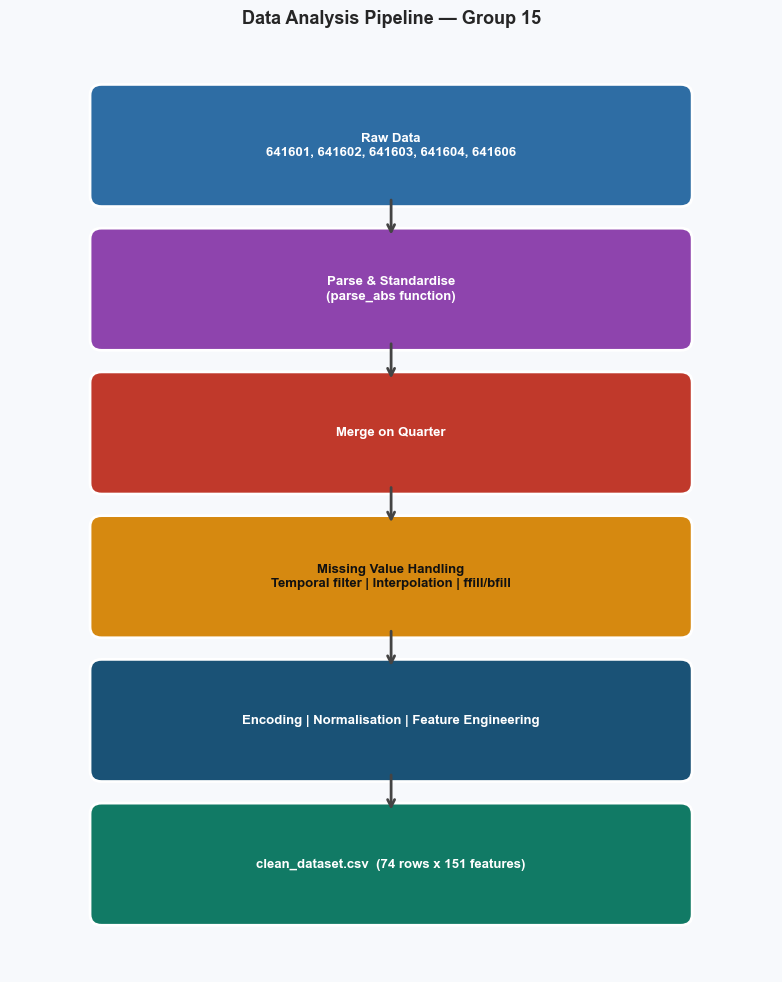

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

boxes = [
    (5, 11.5, 'Raw Data\n641601, 641602, 641603, 641604, 641606',  '#2E6DA4', 'white'),
    (5,  9.5, 'Parse & Standardise\n(parse_abs function)',           '#8E44AD', 'white'),
    (5,  7.5, 'Merge on Quarter',                                     '#C0392B', 'white'),
    (5,  5.5, 'Missing Value Handling\nTemporal filter | Interpolation | ffill/bfill', '#D68910', '#111'),
    (5,  3.5, 'Encoding | Normalisation | Feature Engineering',       '#1A5276', 'white'),
    (5,  1.5, 'clean_dataset.csv  (74 rows x 151 features)',          '#117A65', 'white'),
]
for (x, y, txt, fc, tc) in boxes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-3.8, y-0.7), 7.6, 1.4,
        boxstyle='round,pad=0.15',
        facecolor=fc, edgecolor='white', lw=2, zorder=3))
    ax.text(x, y, txt, ha='center', va='center',
            fontsize=9.5, color=tc, fontweight='bold', zorder=4)

for i in range(len(boxes)-1):
    ax.annotate('', xy=(5, boxes[i+1][1]+0.72), xytext=(5, boxes[i][1]-0.72),
        arrowprops=dict(arrowstyle='->', color='#444', lw=2))

ax.set_title('Data Analysis Pipeline — Group 15', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig0_pipeline.png'), dpi=150, bbox_inches='tight')
plt.show()

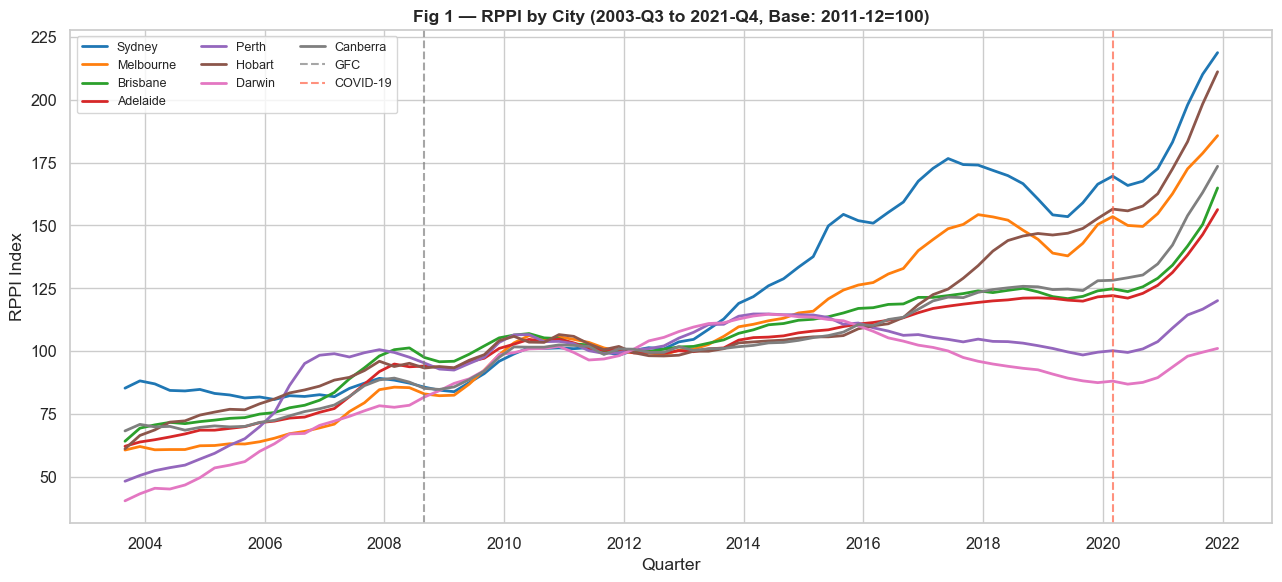

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
for i, c in enumerate(CITIES):
    ax.plot(pd.to_datetime(base['quarter']), base[f'RPPI_{c}'],
            label=c, color=PALETTE[i], lw=2)

ax.axvline(pd.Timestamp('2008-09-01'), color='grey', ls='--', alpha=0.7, label='GFC')
ax.axvline(pd.Timestamp('2020-03-01'), color='tomato', ls='--', alpha=0.7, label='COVID-19')
ax.set_title('Fig 1 — RPPI by City (2003-Q3 to 2021-Q4, Base: 2011-12=100)', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('RPPI Index')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig1_rppi_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

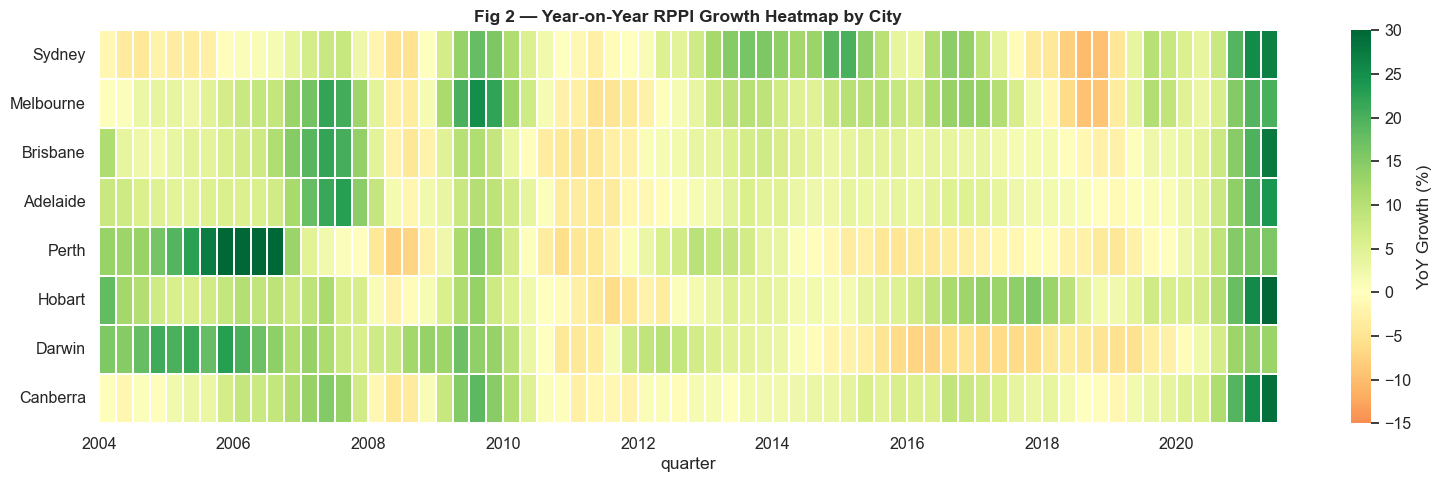

In [14]:
yoy_cols = [f'RPPI_{c}_YoY' for c in CITIES]
yoy_df   = base[['quarter'] + yoy_cols].dropna()
yoy_mat  = yoy_df.set_index('quarter')[yoy_cols].T
yoy_mat.index = CITIES

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(yoy_mat, cmap='RdYlGn', center=0, vmin=-15, vmax=30,
            linewidths=0.3, linecolor='white', ax=ax,
            cbar_kws={'label': 'YoY Growth (%)'})
ticks = list(range(0, len(yoy_mat.columns), 8))
ax.set_xticks(ticks)
ax.set_xticklabels([str(yoy_mat.columns[t].year) for t in ticks], rotation=0)
ax.set_title('Fig 2 — Year-on-Year RPPI Growth Heatmap by City', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig2_yoy_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

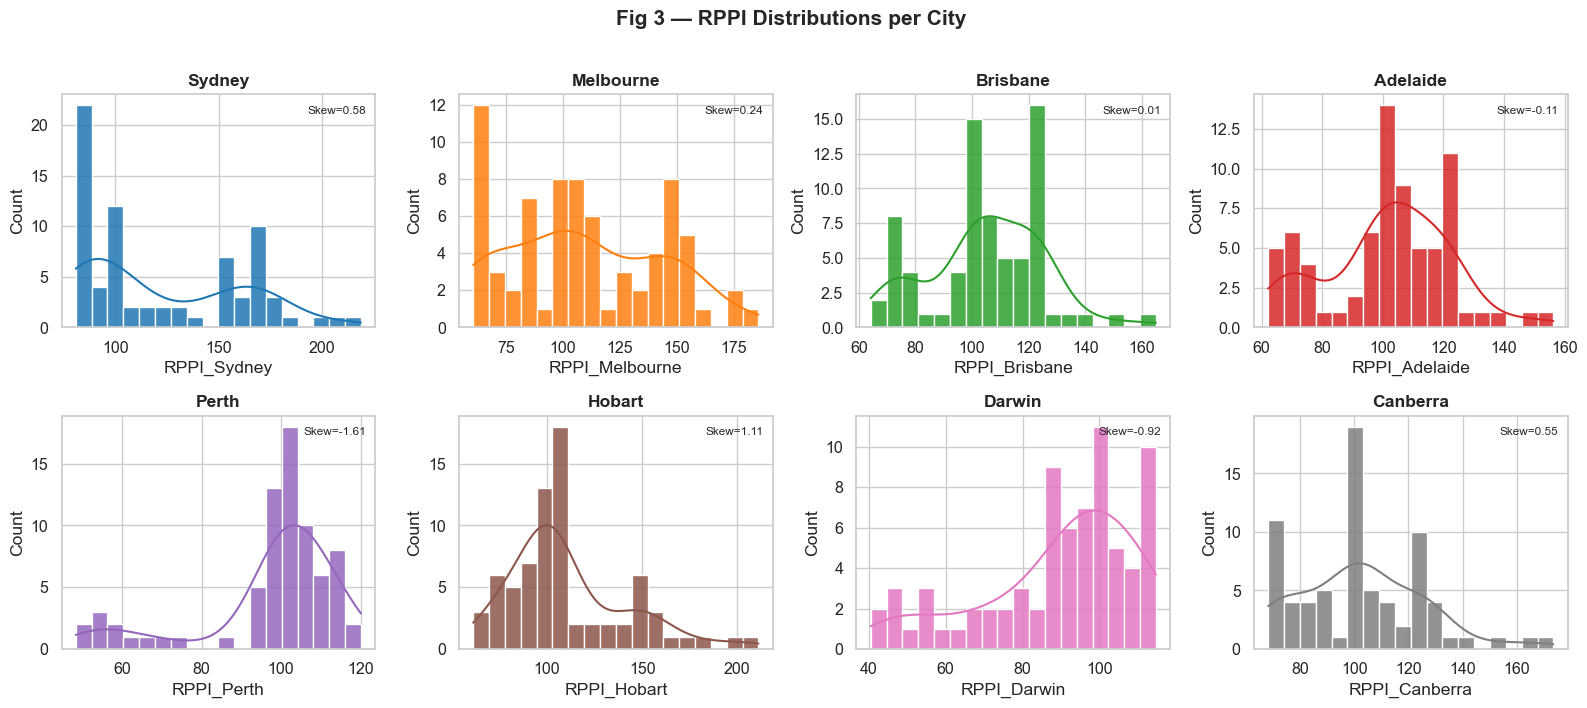

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, c in enumerate(CITIES):
    data = base[f'RPPI_{c}'].dropna()
    sns.histplot(data, kde=True, ax=axes[i],
                 color=PALETTE[i], bins=18, edgecolor='white', alpha=0.85)
    axes[i].set_title(c, fontweight='bold')
    axes[i].text(0.97, 0.95, f"Skew={data.skew():.2f}",
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=8.5)
fig.suptitle('Fig 3 — RPPI Distributions per City', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig3_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

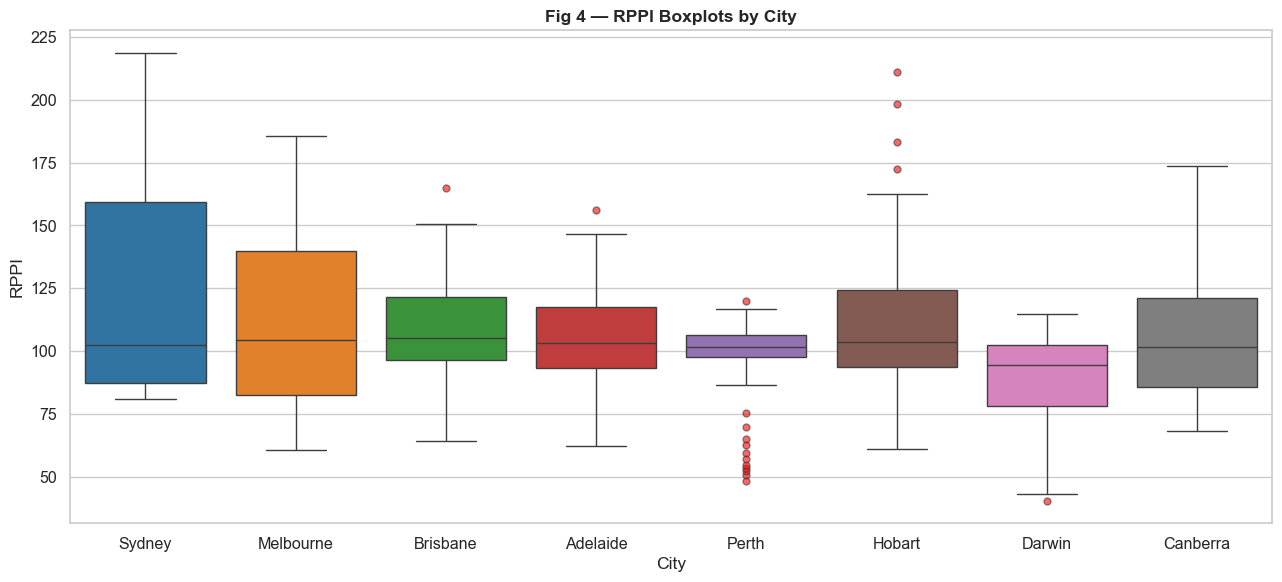

In [16]:
rppi_long = (base[['quarter'] + [f'RPPI_{c}' for c in CITIES]]
             .melt(id_vars='quarter', var_name='City', value_name='RPPI'))
rppi_long['City'] = rppi_long['City'].str.replace('RPPI_', '')

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=rppi_long, x='City', y='RPPI', hue='City',
            palette=PALETTE, ax=ax, legend=False,
            flierprops={'marker':'o','markersize':5,
                        'markerfacecolor':'red','alpha':0.6})
ax.set_title('Fig 4 — RPPI Boxplots by City', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig4_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

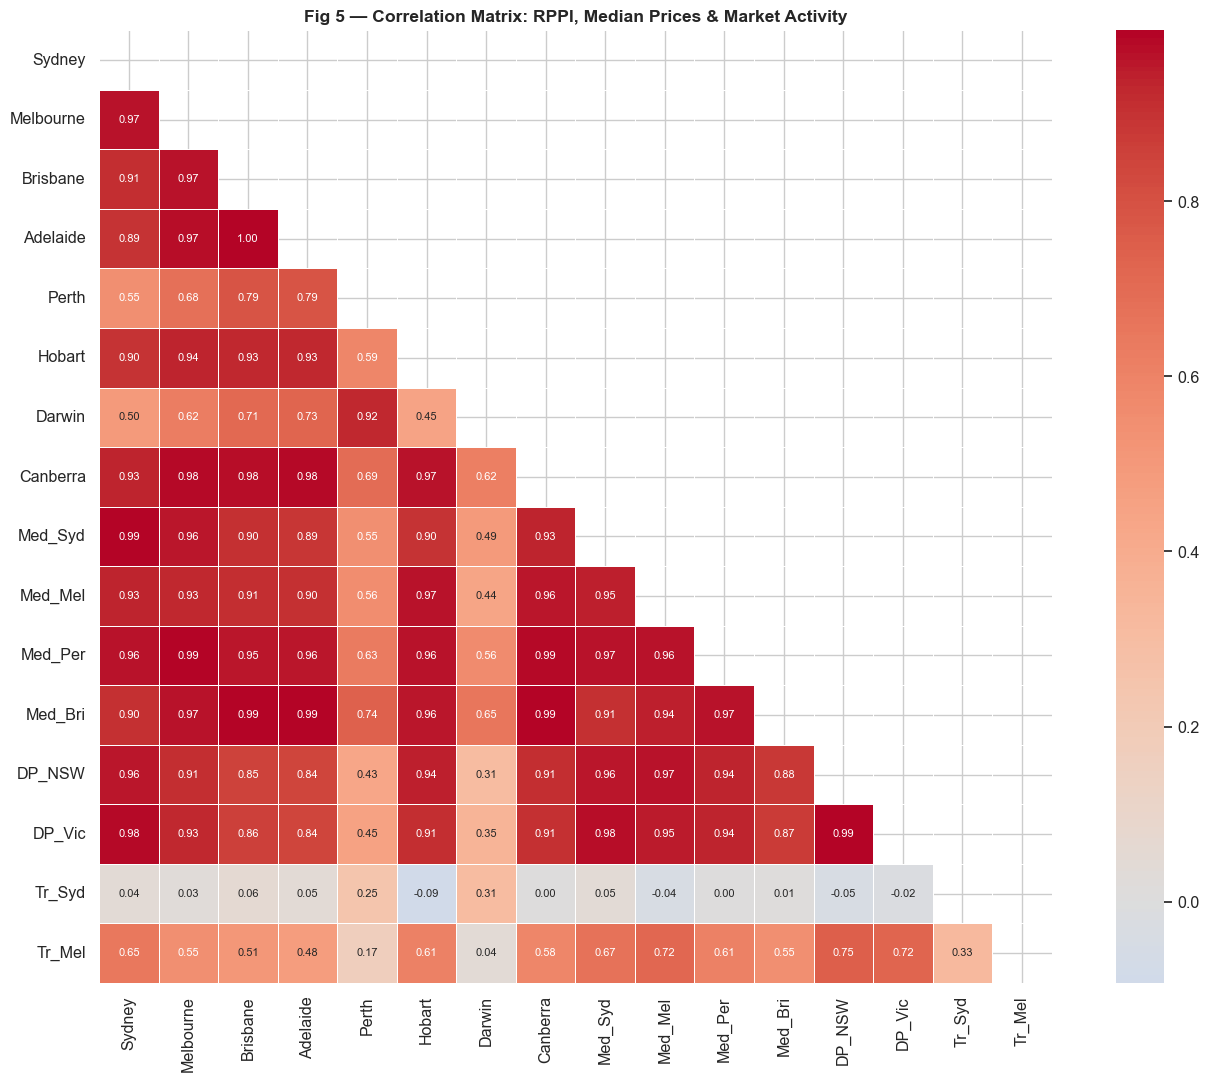

In [17]:
corr_cols = ([f'RPPI_{c}' for c in CITIES] +
             ['MedianHP_Sydney','MedianHP_Melbourne','MedianHP_Brisbane','MedianHP_Perth',
              'MeanDP_NSW','MeanDP_Vic','Transfers_Sydney','Transfers_Melbourne'])
short_names = (CITIES +
               ['Med_Syd','Med_Mel','Med_Per','Med_Bri',
                'DP_NSW','DP_Vic','Tr_Syd','Tr_Mel'])

# keep only cols that exist
valid = [(c, s) for c, s in zip(corr_cols, short_names) if c in base.columns]
corr_cols, short_names = zip(*valid)

corr_data = base[list(corr_cols)].dropna().astype(float).copy()
corr_data.columns = list(short_names)
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_data.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Fig 5 — Correlation Matrix: RPPI, Median Prices & Market Activity',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig5_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

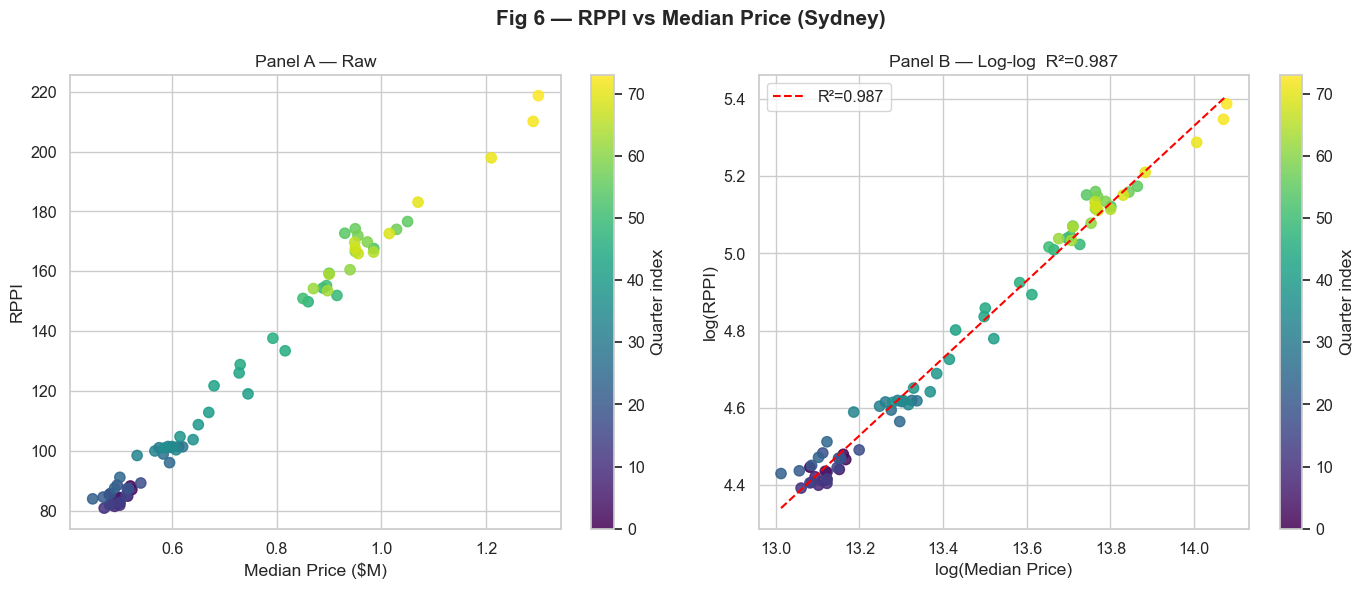

In [18]:
sub = base[['MedianHP_Sydney','RPPI_Sydney','time_idx']].dropna().astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(sub['MedianHP_Sydney']/1e6, sub['RPPI_Sydney'],
                      c=sub['time_idx'], cmap='viridis', s=55, alpha=0.85)
axes[0].set_xlabel('Median Price ($M)')
axes[0].set_ylabel('RPPI')
axes[0].set_title('Panel A — Raw')
plt.colorbar(sc1, ax=axes[0], label='Quarter index')

lx = np.log(sub['MedianHP_Sydney'])
ly = np.log(sub['RPPI_Sydney'])
m, b, r, *_ = stats.linregress(lx, ly)
sc2 = axes[1].scatter(lx, ly, c=sub['time_idx'], cmap='viridis', s=55, alpha=0.85)
xf = np.linspace(lx.min(), lx.max(), 100)
axes[1].plot(xf, m*xf+b, 'r--', lw=1.5, label=f'R²={r**2:.3f}')
axes[1].set_xlabel('log(Median Price)')
axes[1].set_ylabel('log(RPPI)')
axes[1].set_title(f'Panel B — Log-log  R²={r**2:.3f}')
axes[1].legend()
plt.colorbar(sc2, ax=axes[1], label='Quarter index')

fig.suptitle('Fig 6 — RPPI vs Median Price (Sydney)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig6_scatter_rppi_median.png'), dpi=150, bbox_inches='tight')
plt.show()

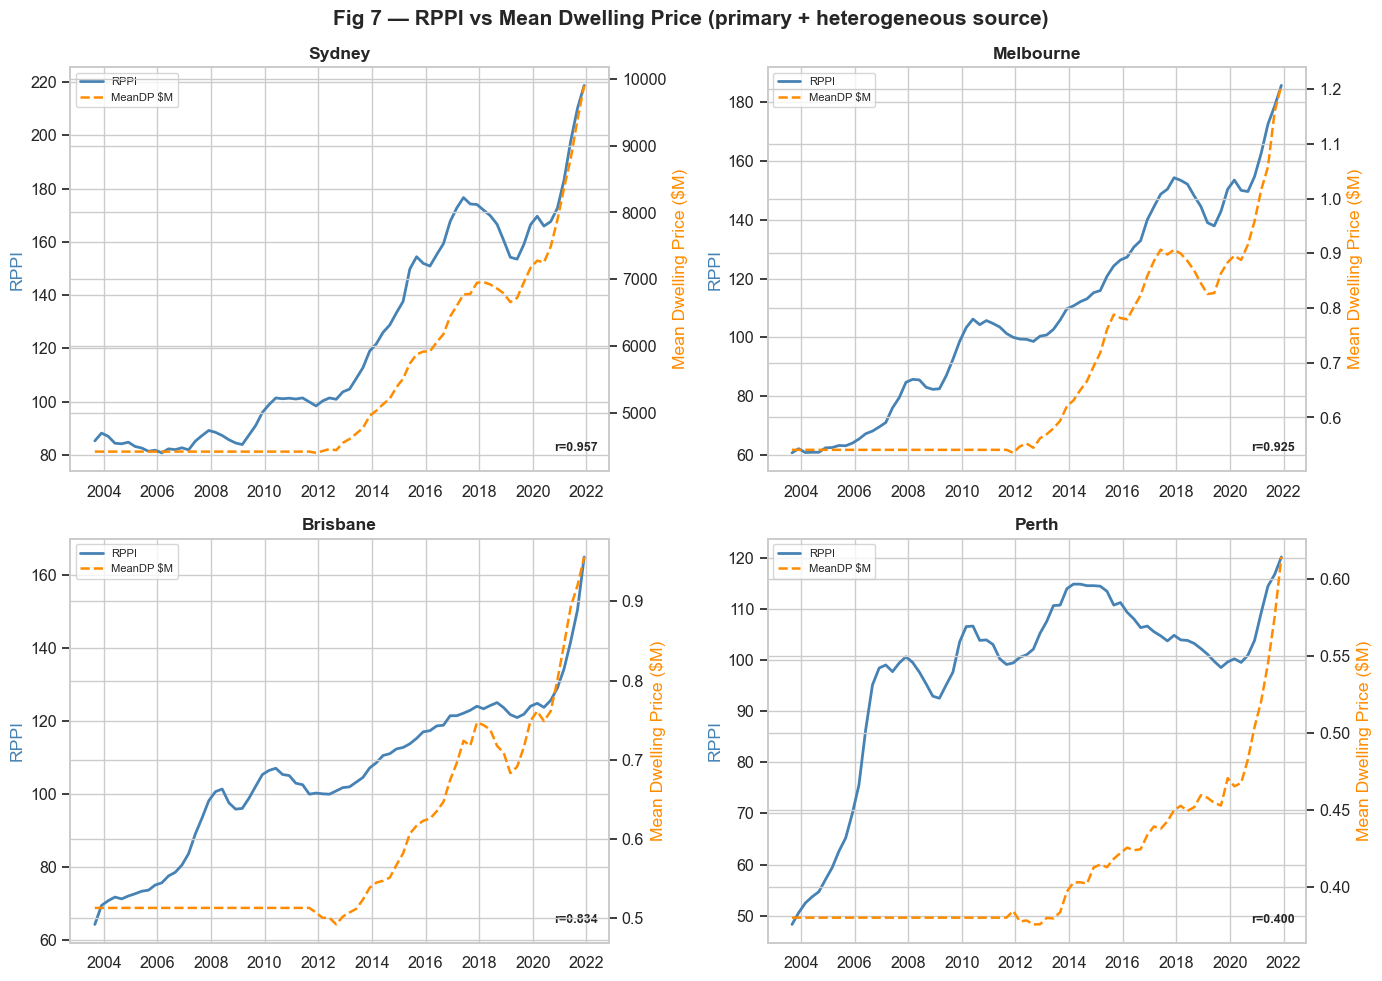

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [('Sydney','NSW'),('Melbourne','Vic'),('Brisbane','Qld'),('Perth','WA')]

for ax, (city, state) in zip(axes.flatten(), pairs):
    dp_col = f'MeanDP_{state}'
    if dp_col not in base.columns:
        ax.set_title(f'{city} — MeanDP_{state} not found')
        continue
    sub = base[['quarter', f'RPPI_{city}', dp_col]].dropna()
    ax2 = ax.twinx()
    ax.plot(pd.to_datetime(sub['quarter']),
            sub[f'RPPI_{city}'], color='steelblue', lw=2, label='RPPI')
    ax2.plot(pd.to_datetime(sub['quarter']),
             sub[dp_col]/1e6, color='darkorange', ls='--', lw=1.8, label='MeanDP $M')
    r = np.corrcoef(sub[f'RPPI_{city}'].astype(float),
                    sub[dp_col].astype(float))[0, 1]
    ax.set_title(f'{city}', fontweight='bold')
    ax.set_ylabel('RPPI', color='steelblue')
    ax2.set_ylabel('Mean Dwelling Price ($M)', color='darkorange')
    ax.text(0.98, 0.05, f'r={r:.3f}', transform=ax.transAxes,
            ha='right', fontsize=9, fontweight='bold')
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8)

fig.suptitle('Fig 7 — RPPI vs Mean Dwelling Price (primary + heterogeneous source)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig7_hetero_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

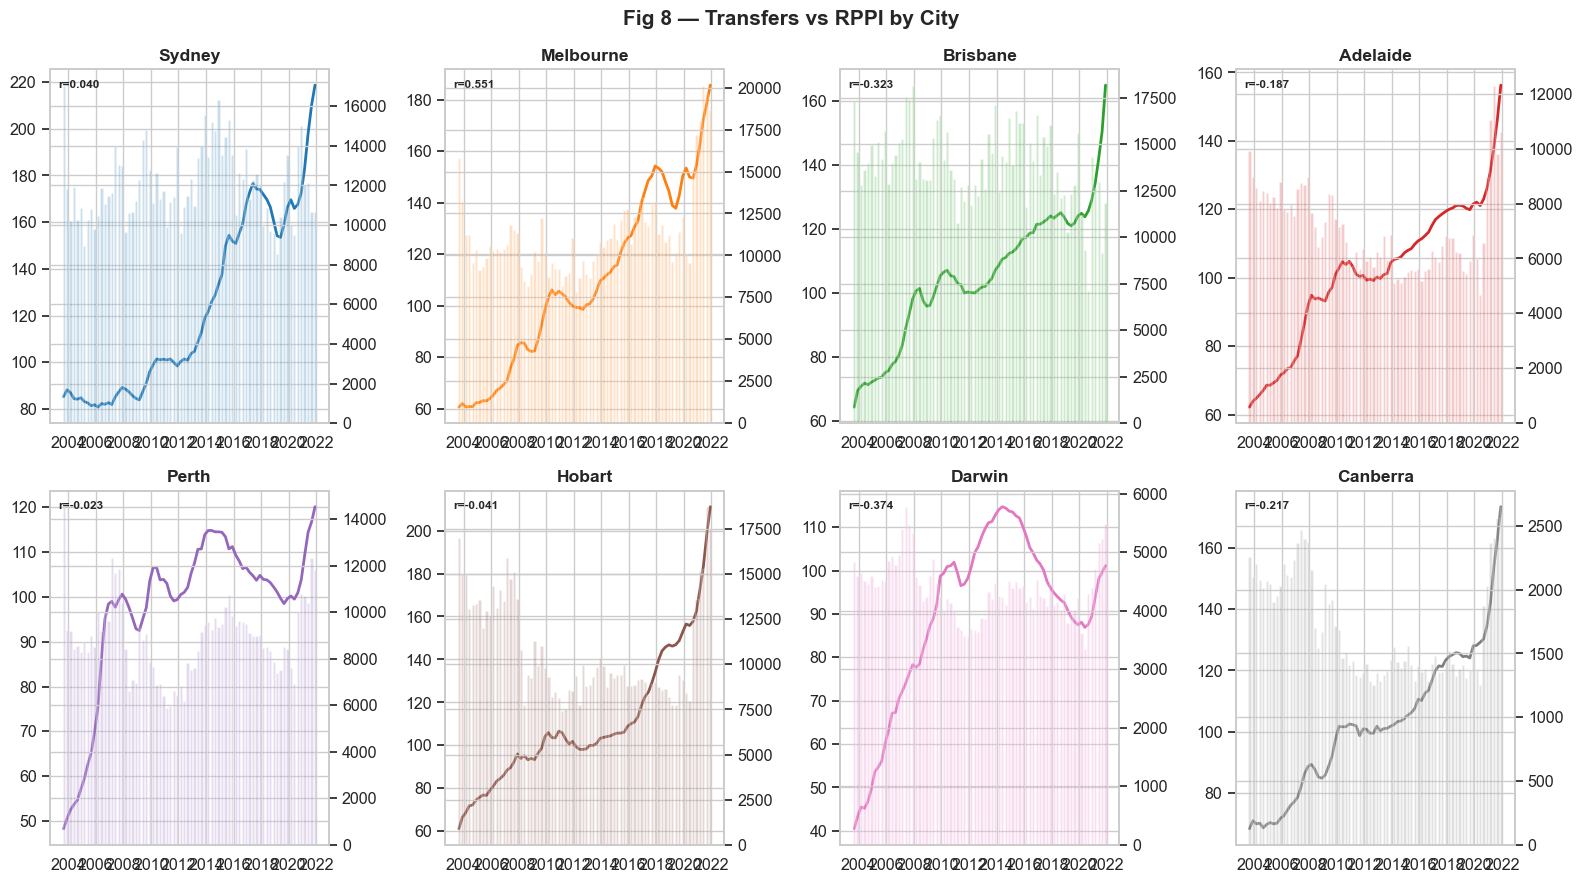

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(CITIES):
    sub = base[['quarter', f'RPPI_{c}', f'Transfers_{c}']].dropna()
    ax2 = axes[i].twinx()
    axes[i].plot(pd.to_datetime(sub['quarter']),
                 sub[f'RPPI_{c}'], color=PALETTE[i], lw=2)
    ax2.bar(pd.to_datetime(sub['quarter']),
            sub[f'Transfers_{c}'], color=PALETTE[i], alpha=0.25, width=60)
    r = np.corrcoef(sub[f'RPPI_{c}'].astype(float),
                    sub[f'Transfers_{c}'].astype(float))[0, 1]
    axes[i].set_title(c, fontweight='bold')
    axes[i].text(0.03, 0.97, f'r={r:.3f}', transform=axes[i].transAxes,
                 ha='left', va='top', fontsize=8.5, fontweight='bold')

fig.suptitle('Fig 8 — Transfers vs RPPI by City', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig8_transfers_rppi.png'), dpi=150, bbox_inches='tight')
plt.show()

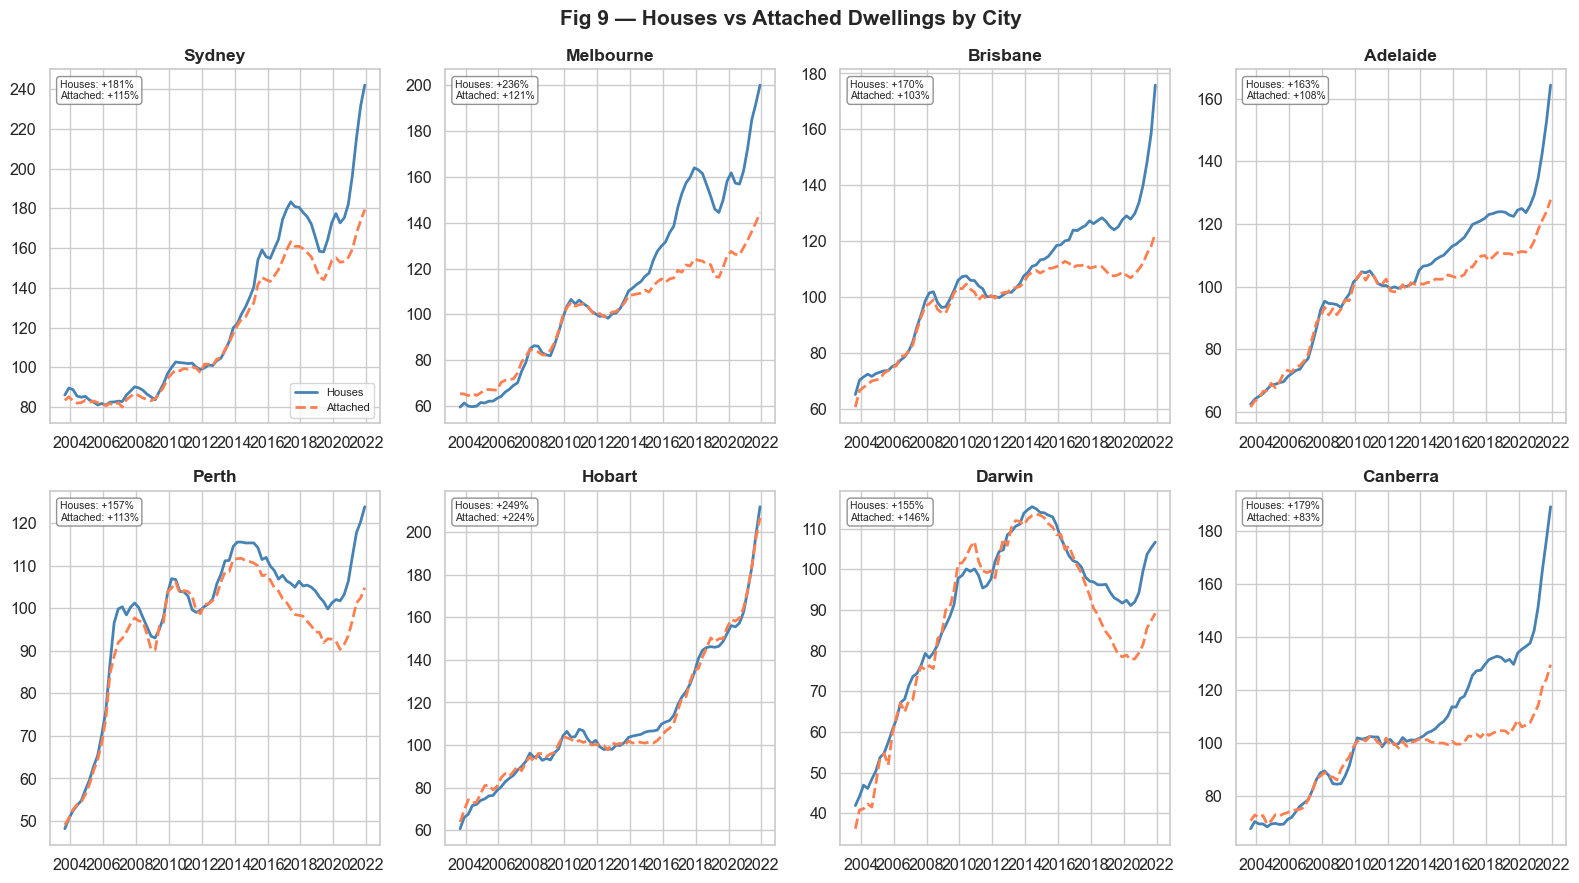

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(CITIES):
    sub = base[['quarter', f'EHPI_{c}', f'ADPI_{c}']].dropna()
    axes[i].plot(pd.to_datetime(sub['quarter']),
                 sub[f'EHPI_{c}'], color='steelblue', lw=2, label='Houses')
    axes[i].plot(pd.to_datetime(sub['quarter']),
                 sub[f'ADPI_{c}'], color='coral', ls='--', lw=2, label='Attached')
    eg = (sub[f'EHPI_{c}'].iloc[-1] / sub[f'EHPI_{c}'].iloc[0] - 1) * 100
    ag = (sub[f'ADPI_{c}'].iloc[-1] / sub[f'ADPI_{c}'].iloc[0] - 1) * 100
    axes[i].set_title(c, fontweight='bold')
    axes[i].text(0.03, 0.97,
                 f'Houses: +{eg:.0f}%\nAttached: +{ag:.0f}%',
                 transform=axes[i].transAxes, ha='left', va='top', fontsize=7.5,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='grey', alpha=0.85))
    if i == 0:
        axes[i].legend(fontsize=8)

fig.suptitle('Fig 9 — Houses vs Attached Dwellings by City', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS, 'fig9_house_vs_attached.png'), dpi=150, bbox_inches='tight')
plt.show()

In [22]:
desc = base[[f'RPPI_{c}' for c in CITIES]].astype(float).describe().T
desc.index = CITIES
desc['skewness']      = [base[f'RPPI_{c}'].skew() for c in CITIES]
desc['total_growth_%'] = [(base[f'RPPI_{c}'].dropna().iloc[-1] /
                            base[f'RPPI_{c}'].dropna().iloc[0] - 1) * 100
                           for c in CITIES]
print(desc[['mean','std','min','max','skewness','total_growth_%']].round(2))
desc.round(2).to_csv(os.path.join(CLEAN, 'descriptive_stats.csv'))

print(f"\nEDA complete — {len(os.listdir(GRAPHS))} figures saved to EDA_Graphs/")
print(f"clean_dataset.csv saved to Clean_Dataset/")

             mean    std   min    max  skewness  total_growth_%
Sydney     122.91  38.78  80.8  218.7      0.58          156.39
Melbourne  109.29  33.86  60.7  185.7      0.24          205.93
Brisbane   105.16  20.42  64.2  164.9      0.01          156.85
Adelaide   101.51  20.51  62.2  156.3     -0.11          151.29
Perth       97.41  17.57  48.3  120.1     -1.61          148.65
Hobart     110.80  31.02  61.2  211.1      1.11          244.93
Darwin      89.27  20.10  40.5  114.7     -0.92          149.63
Canberra   102.74  23.14  68.3  173.5      0.55          154.03

EDA complete — 10 figures saved to EDA_Graphs/
clean_dataset.csv saved to Clean_Dataset/
